In [28]:
import pandas as pd
from pathlib import Path

csv_path = "../Clustering/clustering_Cleaned.csv"
df_full = pd.read_csv(csv_path)  # Keep full dataframe for later merging

# Drop specified columns
cols_to_drop = ['card_transaction_count', 'Credit_Amount_Total', 'Debit_Amount_Total']
cols_to_drop = [col for col in cols_to_drop if col in df_full.columns]
if cols_to_drop:
    df_full = df_full.drop(columns=cols_to_drop)
    print(f"Dropped columns: {cols_to_drop}")
else:
    print("No specified columns found to drop")

# Filter for business only
df = df_full[df_full['kyc_type'].str.lower() == 'business'].copy()
print(f"Full dataset: {len(df_full)} rows")
print(f"Filtered to business customers only: {len(df)} rows")

df.head()

Dropped columns: ['card_transaction_count', 'Credit_Amount_Total', 'Debit_Amount_Total']
Full dataset: 61410 rows
Filtered to business customers only: 8311 rows


,customer_id,kyc_type,province,city,industry_code,occupation_code,sales_cents,account_age,birth_business_age,total_transaction_count,...,card_top_mcc,card_second_mcc,abm_transaction_count,abm_cash_count,abm_non_cash_count,abm_cash_to_non_cash_ratio,Averagetime_between_alltransaction,std_time_between_transactions,median_time_between_transactions,pct_transactions_top10_busiest_days
10,SYNID0200173949,business,other,other,8599,NaN,815398.0,NaN,12.89,44,...,NaN,NaN,NaN,NaN,NaN,NaN,2.085914,2.032809,1.290162,22.727273
21,SYNID0200189622,business,ON,RICHMOND HILL,9953,NaN,0.0,4.01,4.17,17,...,NaN,NaN,NaN,NaN,NaN,NaN,5.062509,4.861127,3.070903,23.529412
28,SYNID0200153723,business,ON,ETOBICOKE,4561,NaN,0.0,3.27,3.41,212,...,5814,0,12.0,9.0,3.0,3.0,0.434553,0.514694,0.315417,22.169811
40,SYNID0200639184,business,AB,EDMONTON,9211,NaN,54090.0,12.04,12.25,55,...,5411,5542,NaN,NaN,NaN,NaN,1.669937,1.807573,1.077708,27.272727
51,SYNID0200759913,business,other,other,Other,NaN,31531.0,12.19,12.23,111,...,5541,0,NaN,NaN,NaN,NaN,0.828332,0.917498,0.527222,22.522523


In [29]:
df.isna().sum()

customer_id                                0
kyc_type                                   0
province                                   0
city                                       0
industry_code                             20
occupation_code                         8311
sales_cents                                0
account_age                              754
birth_business_age                       410
total_transaction_count                    0
transaction_count_ABM                      0
transaction_count_Card                     0
transaction_count_Cheque                   0
transaction_count_EFT                      0
transaction_count_EMT                      0
transaction_count_Western Union            0
transaction_count_Wire                     0
debit_transaction_count                  207
debit_transaction_amount                 207
credit_transaction_count                 425
credit_transaction_amount                425
average_debit_transaction_amount         207
average_cr

In [30]:
# Keep industry_code for business, drop occupation_code
import numpy as np

# Drop occupation_code (not needed for business)
df = df.drop(columns=["occupation_code"])

# Convert industry_code to categorical dtype (recommended for FAMD)
df["industry_code"] = df["industry_code"].astype("category")

# Quick sanity checks
print("industry_code nunique:", df["industry_code"].nunique())
print(df["industry_code"].value_counts().head(10))

industry_code nunique: 169
industry_code
Other    1528
7215      661
7771      429
4561      344
7292      248
4013      232
8651      231
7761      173
7799      150
7721      133
Name: count, dtype: int64


In [31]:
# Replace industry_code values that appear less than 50 times with "Other"
if 'industry_code' in df.columns:
    # Count frequency of each industry_code
    industry_code_counts = df['industry_code'].value_counts()
    
    # Find industry_code values that appear less than 50 times (excluding NaN)
    rare_industry_codes = industry_code_counts[industry_code_counts < 50].index.tolist()
    
    print(f"Found {len(rare_industry_codes)} industry_code values appearing less than 50 times")
    
    # Create mask for rows with rare industry_code values
    rare_mask = df['industry_code'].isin(rare_industry_codes)
    print(f"Total rows to be changed: {rare_mask.sum()}")
    
    # Replace rare industry_code values with "Other"
    df.loc[rare_mask, 'industry_code'] = 'Other'
    
    # Convert back to category after replacement
    df['industry_code'] = df['industry_code'].astype('category')
    
    # Show updated distribution
    print(f"\nUpdated industry_code distribution:")
    print(df['industry_code'].value_counts().head(10))
else:
    print("Column 'industry_code' not found in dataframe")

Found 136 industry_code values appearing less than 50 times
Total rows to be changed: 2420

Updated industry_code distribution:
industry_code
Other    3948
7215      661
7771      429
4561      344
7292      248
4013      232
8651      231
7761      173
7799      150
7721      133
Name: count, dtype: int64


In [32]:
# 2. account_age and birth_business_age: fill nulls with median
# Fill with median
df['account_age'] = df['account_age'].fillna(df['account_age'].median())
df['birth_business_age'] = df['birth_business_age'].fillna(df['birth_business_age'].median())

In [33]:
# 3. Fill debit and credit nulls to 0
debit_credit_cols = [
    'debit_transaction_count',
    'debit_transaction_amount',
    'average_debit_transaction_amount',
    'credit_transaction_count',
    'credit_transaction_amount',
    'average_credit_transaction_amount'
]

for col in debit_credit_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [34]:
# 4. Fill nulls in columns with prefix 'card_' or 'abm_' to 0
card_abm_cols = [col for col in df.columns if col.startswith('card_') or col.startswith('abm_')]
for col in card_abm_cols:
    if col == 'card_top_mcc':
        df[col] = df[col].fillna('N/A')
    elif col == 'card_second_mcc':
        df[col] = df[col].fillna('N/A')
    elif col=='card_ecommerce_to_nonecommerce_ratio':
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(0)

In [35]:
# 6. Replace MCC codes in card_top_mcc that appear less than 100 times with "other"
if 'card_top_mcc' in df.columns:
    # Count frequency of each MCC code
    mcc_counts = df['card_top_mcc'].value_counts()
    
    # Find MCC codes that appear less than 100 times (excluding N/A and null)
    rare_mccs = mcc_counts[mcc_counts < 100].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_mccs:
        rare_mccs.remove('N/A')
    
    print(f"Found {len(rare_mccs)} MCC codes appearing less than 100 times")
    print(f"Total rows to be changed: {df['card_top_mcc'].isin(rare_mccs).sum()}")
    
    # Replace rare MCC codes with "other"
    df.loc[df['card_top_mcc'].isin(rare_mccs), 'card_top_mcc'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated card_top_mcc distribution:")
    print(df['card_top_mcc'].value_counts().head(10))
else:
    print("Column 'card_top_mcc' not found in dataframe")

Found 64 MCC codes appearing less than 100 times
Total rows to be changed: 636

Updated card_top_mcc distribution:
card_top_mcc
N/A      4234
other     902
0         865
5411      499
5814      460
5541      434
5542      336
5251      165
4816      154
5812      153
Name: count, dtype: int64


In [36]:
# 7. Replace cities that appear less than 100 times with "other"
if 'city' in df.columns:
    # Count frequency of each city
    city_counts = df['city'].value_counts()
    
    # Find cities that appear less than 100 times (excluding N/A and null)
    rare_cities = city_counts[city_counts < 100].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_cities:
        rare_cities.remove('N/A')
    
    print(f"Found {len(rare_cities)} cities appearing less than 100 times")
    print(f"Total rows to be changed: {df['city'].isin(rare_cities).sum()}")
    
    # Replace rare cities with "other"
    df.loc[df['city'].isin(rare_cities), 'city'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated city distribution:")
    print(df['city'].value_counts().head(10))
else:
    print("Column 'city' not found in dataframe")

Found 139 cities appearing less than 100 times
Total rows to be changed: 3073

Updated city distribution:
city
other          5988
TORONTO         562
CALGARY         368
EDMONTON        242
BRAMPTON        229
OTTAWA          181
MISSISSAUGA     159
VANCOUVER       142
SCARBOROUGH     122
WINNIPEG        108
Name: count, dtype: int64


In [37]:
# 5. Remove customer_id and card_second_mcc, but KEEP sales_cents for business
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])
if 'card_second_mcc' in df.columns:
    df = df.drop(columns=['card_second_mcc'])

# Drop transaction count columns for Western Union and Wire
if 'transaction_count_Western Union' in df.columns:
    df = df.drop(columns=['transaction_count_Western Union'])
if 'transaction_count_Wire' in df.columns:
    df = df.drop(columns=['transaction_count_Wire'])

# Drop ABM count columns
if 'abm_cash_count' in df.columns:
    df = df.drop(columns=['abm_cash_count'])
if 'abm_non_cash_count' in df.columns:
    df = df.drop(columns=['abm_non_cash_count'])

# Drop ABM transaction count columns
if 'abm_transaction_count' in df.columns:
    df = df.drop(columns=['abm_transaction_count'])
if 'transaction_count_ABM' in df.columns:
    df = df.drop(columns=['transaction_count_ABM'])

# Drop abm_cash_to_non_cash_ratio
if 'abm_cash_to_non_cash_ratio' in df.columns:
    df = df.drop(columns=['abm_cash_to_non_cash_ratio'])
    print("Dropped 'abm_cash_to_non_cash_ratio' column")

# Note: sales_cents is kept for business analysis

# Handle the three new columns: Debit_Amount_Total, Credit_Amount_Total, Averagetime_between_alltransaction
# Rename Averagetime_between_alltransaction to Averagetime_between_transaction_day
if 'Averagetime_between_alltransaction' in df.columns:
    df = df.rename(columns={'Averagetime_between_alltransaction': 'Averagetime_between_transaction_day'})
    print("Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'")

# Fill Debit_Amount_Total and Credit_Amount_Total with 0
for col in ['Debit_Amount_Total', 'Credit_Amount_Total']:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        print(f"Filled null values in '{col}' with 0")
    else:
        print(f"Warning: Column '{col}' not found in dataframe")

# Fill Averagetime_between_transaction_day with median (not 0)
if 'Averagetime_between_transaction_day' in df.columns:
    median_value = df['Averagetime_between_transaction_day'].median()
    df['Averagetime_between_transaction_day'] = df['Averagetime_between_transaction_day'].fillna(median_value)
    print(f"Filled null values in 'Averagetime_between_transaction_day' with median: {median_value:.4f}")
else:
    print("Warning: Column 'Averagetime_between_transaction_day' not found in dataframe")

# Fill the three new time-based columns
# Fill std_time_between_transactions with median
if 'std_time_between_transactions' in df.columns:
    median_value = df['std_time_between_transactions'].median()
    df['std_time_between_transactions'] = df['std_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'std_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'std_time_between_transactions' not found in dataframe")

# Fill median_time_between_transactions with median
if 'median_time_between_transactions' in df.columns:
    median_value = df['median_time_between_transactions'].median()
    df['median_time_between_transactions'] = df['median_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'median_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'median_time_between_transactions' not found in dataframe")

# pct_transactions_top10_busiest_days does not have NA values, so no filling needed
if 'pct_transactions_top10_busiest_days' in df.columns:
    na_count = df['pct_transactions_top10_busiest_days'].isna().sum()
    print(f"Column 'pct_transactions_top10_busiest_days' has {na_count} NA values (no filling needed)")
else:
    print("Warning: Column 'pct_transactions_top10_busiest_days' not found in dataframe")

Dropped 'abm_cash_to_non_cash_ratio' column
Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'
Filled null values in 'Averagetime_between_transaction_day' with median: 2.4700
Filled null values in 'std_time_between_transactions' with median: 2.3699
Filled null values in 'median_time_between_transactions' with median: 1.2574
Column 'pct_transactions_top10_busiest_days' has 0 NA values (no filling needed)


In [38]:
# Count number of categories for each categorical column after small category removal
print("=" * 80)
print("CATEGORICAL COLUMNS - NUMBER OF CATEGORIES")
print("=" * 80)

# Identify categorical columns (object dtype and category dtype)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove kyc_type since it's constant (all business)
if 'kyc_type' in categorical_cols:
    categorical_cols.remove('kyc_type')
    df = df.drop(columns=['kyc_type'])

# Create summary dataframe
category_summary = []

for col in categorical_cols:
    n_unique = df[col].nunique()
    n_null = df[col].isna().sum()
    category_summary.append({
        'Column': col,
        'Number of Categories': n_unique,
        'Null Count': n_null,
        'Dtype': str(df[col].dtype)
    })

category_df = pd.DataFrame(category_summary)
category_df = category_df.sort_values('Number of Categories', ascending=False)

print(f"\nFound {len(categorical_cols)} categorical columns:\n")
print(category_df.to_string(index=False))

print("\n" + "=" * 80)
print("SUMMARY:")
print(f"Total categorical columns: {len(categorical_cols)}")
print(f"Average categories per column: {category_df['Number of Categories'].mean():.1f}")
print(f"Max categories: {category_df['Number of Categories'].max()} ({category_df.loc[category_df['Number of Categories'].idxmax(), 'Column']})")
print(f"Min categories: {category_df['Number of Categories'].min()} ({category_df.loc[category_df['Number of Categories'].idxmin(), 'Column']})")
print("=" * 80)

CATEGORICAL COLUMNS - NUMBER OF CATEGORIES

Found 4 categorical columns:

       Column  Number of Categories  Null Count    Dtype
industry_code                    33          20 category
     province                    12           0   object
         city                    12           0   object
 card_top_mcc                    11           0   object

SUMMARY:
Total categorical columns: 4
Average categories per column: 17.0
Max categories: 33 (industry_code)
Min categories: 11 (card_top_mcc)


In [39]:
# Standardize "Other" to "other" (lowercase) in all categorical columns to avoid case mismatch
print("=" * 80)
print("STANDARDIZING 'other' VALUES")
print("=" * 80)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Standardize "Other" (capitalized) to "other" (lowercase) in all categorical columns
changes_made = {}
for col in categorical_cols:
    if df[col].dtype == 'category':
        # For category dtype, check if "Other" exists
        if 'Other' in df[col].cat.categories:
            # Count how many will be changed
            count = (df[col] == 'Other').sum()
            if count > 0:
                # Replace "Other" with "other"
                df[col] = df[col].cat.rename_categories({'Other': 'other'})
                changes_made[col] = count
    else:
        # For object dtype, replace "Other" with "other"
        count = (df[col] == 'Other').sum()
        if count > 0:
            df[col] = df[col].replace('Other', 'other')
            changes_made[col] = count

if changes_made:
    print(f"\nStandardized 'Other' to 'other' in {len(changes_made)} column(s):")
    for col, count in changes_made.items():
        print(f"  - {col}: {count} value(s) changed")
else:
    print("\nNo 'Other' (capitalized) values found - all 'other' values are already lowercase")

print("\n" + "=" * 80)

STANDARDIZING 'other' VALUES

Standardized 'Other' to 'other' in 1 column(s):
  - industry_code: 3948 value(s) changed



In [40]:
print("=" * 80)
print("DATA TYPE CLEANUP")
print("=" * 80)

# 2. Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical columns (will be preserved): {categorical_cols}")

# 3. Convert all non-categorical columns to float64
non_categorical_cols = [col for col in df.columns if col not in categorical_cols]
print(f"\nConverting {len(non_categorical_cols)} non-categorical columns to float64...")

conversion_summary = []
for col in non_categorical_cols:
    old_dtype = str(df[col].dtype)
    df[col] = df[col].astype('float64')
    new_dtype = str(df[col].dtype)
    conversion_summary.append({
        'Column': col,
        'Old Dtype': old_dtype,
        'New Dtype': new_dtype
    })

print(f"✓ Converted {len(non_categorical_cols)} columns to float64")

# Show dtype summary
print("\n" + "=" * 80)
print("FINAL DATA TYPE SUMMARY:")
print("=" * 80)
print(f"Total columns: {len(df.columns)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Float64 columns: {len(non_categorical_cols)}")
print(f"\nUnique dtypes: {df.dtypes.value_counts().to_dict()}")
print("=" * 80)

DATA TYPE CLEANUP

Categorical columns (will be preserved): ['province', 'city', 'industry_code', 'card_top_mcc']

Converting 26 non-categorical columns to float64...
✓ Converted 26 columns to float64

FINAL DATA TYPE SUMMARY:
Total columns: 30
Categorical columns: 4
Float64 columns: 26

Unique dtypes: {dtype('float64'): 26, dtype('O'): 3, CategoricalDtype(categories=['0112', '0119', '0139', '0141', '0171', '0211', '0219',
                  '0311', '0411', '0511',
                  ...
                  '9851', '9861', '9931', '9942', '9949', '9953', '9959',
                  '9962', '9999', 'other'],
, ordered=False, categories_dtype=object): 1}


In [41]:
import prince
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Test different n_components values
n_components_list = [6, 8, 10, 12, 15]
df_famd = df.copy()

print(f"Testing FAMD with different n_components on full dataset with {len(df_famd)} rows...")
print("=" * 80)

# Store results for each n_components
all_results = {}

for n_comp in n_components_list:
    print(f"\n{'='*80}")
    print(f"Fitting FAMD with n_components={n_comp}...")
    print(f"{'='*80}")
    
    # Fit FAMD
    famd = prince.FAMD(
        n_components=n_comp,
        n_iter=3,
        copy=True,
        check_input=True,
        random_state=42,
        engine="sklearn",
        handle_unknown="error"
    )
    
    famd = famd.fit(df_famd)
    print(f"FAMD fitting completed for n_components={n_comp}!")
    
    # Extract row coordinates (FAMD component scores)
    X_famd = famd.row_coordinates(df_famd)
    X = np.asarray(X_famd.iloc[:, :n_comp], dtype=np.float32, order="C")
    
    print(f"FAMD scores shape: {X.shape}")
    
    # Test different k values for clustering
    k_list = list(range(4, 12))
    sil_scores = []
    inertia_scores = []
    
    print(f"\nTesting K-means clustering with k values: {k_list}")
    for k in k_list:
        km = KMeans(n_clusters=k, n_init="auto", random_state=42)
        labels = km.fit_predict(X)
        s = silhouette_score(X, labels)
        sil_scores.append(s)
        inertia_scores.append(km.inertia_)
        print(f"  k={k}: silhouette={s:.4f}, inertia={km.inertia_:.2f}")
    
    # Store results
    all_results[n_comp] = {
        'k_list': k_list,
        'silhouette': sil_scores,
        'inertia': inertia_scores,
        'X': X,
        'famd': famd
    }
    
    print(f"\nCompleted n_components={n_comp}")

print("\n" + "=" * 80)
print("All FAMD n_components tested!")
print("=" * 80)

Testing FAMD with different n_components on full dataset with 8311 rows...

Fitting FAMD with n_components=6...
FAMD fitting completed for n_components=6!
FAMD scores shape: (8311, 6)

Testing K-means clustering with k values: [4, 5, 6, 7, 8, 9, 10, 11]
  k=4: silhouette=0.2189, inertia=128474.69
  k=5: silhouette=0.2900, inertia=104680.28
  k=6: silhouette=0.3304, inertia=89372.33
  k=7: silhouette=0.3456, inertia=74339.16
  k=8: silhouette=0.3131, inertia=68758.51
  k=9: silhouette=0.3468, inertia=55863.25
  k=10: silhouette=0.3325, inertia=51949.16
  k=11: silhouette=0.3378, inertia=48087.94

Completed n_components=6

Fitting FAMD with n_components=8...
FAMD fitting completed for n_components=8!
FAMD scores shape: (8311, 8)

Testing K-means clustering with k values: [4, 5, 6, 7, 8, 9, 10, 11]
  k=4: silhouette=0.3428, inertia=159658.14
  k=5: silhouette=0.2101, inertia=144024.47
  k=6: silhouette=0.2503, inertia=126101.80
  k=7: silhouette=0.2745, inertia=110070.82
  k=8: silhouette

In [42]:
# Display column contributions for n_components=10 (as reference)
if 10 in all_results:
    print("Column contributions for n_components=10:")
    display(all_results[10]['famd'].column_contributions_.style.format('{:.2%}'))

Column contributions for n_components=10:


component,0,1,2,3,4,5,6,7,8,9
variable,,,,,,,,,,
sales_cents,0.02%,0.05%,0.00%,0.00%,0.14%,0.13%,0.00%,0.19%,0.05%,0.17%
account_age,0.04%,0.13%,0.02%,0.21%,0.76%,1.06%,0.37%,0.62%,0.97%,1.00%
birth_business_age,0.06%,0.15%,0.01%,0.26%,0.69%,1.09%,0.40%,0.65%,0.96%,0.89%
total_transaction_count,3.72%,13.96%,0.13%,0.00%,0.04%,0.00%,0.04%,0.00%,0.02%,0.00%
transaction_count_Card,9.21%,0.81%,0.01%,0.00%,0.07%,0.08%,3.51%,0.06%,0.00%,0.09%
transaction_count_Cheque,0.20%,3.77%,0.01%,0.05%,0.02%,0.07%,0.02%,0.00%,0.00%,0.00%
transaction_count_EFT,0.65%,13.89%,0.13%,0.00%,0.03%,0.01%,0.07%,0.00%,0.02%,0.00%
transaction_count_EMT,0.21%,0.64%,0.00%,0.03%,0.10%,0.02%,0.14%,0.00%,0.05%,0.05%
debit_transaction_count,6.64%,7.91%,0.10%,0.00%,0.01%,0.00%,0.53%,0.01%,0.01%,0.01%


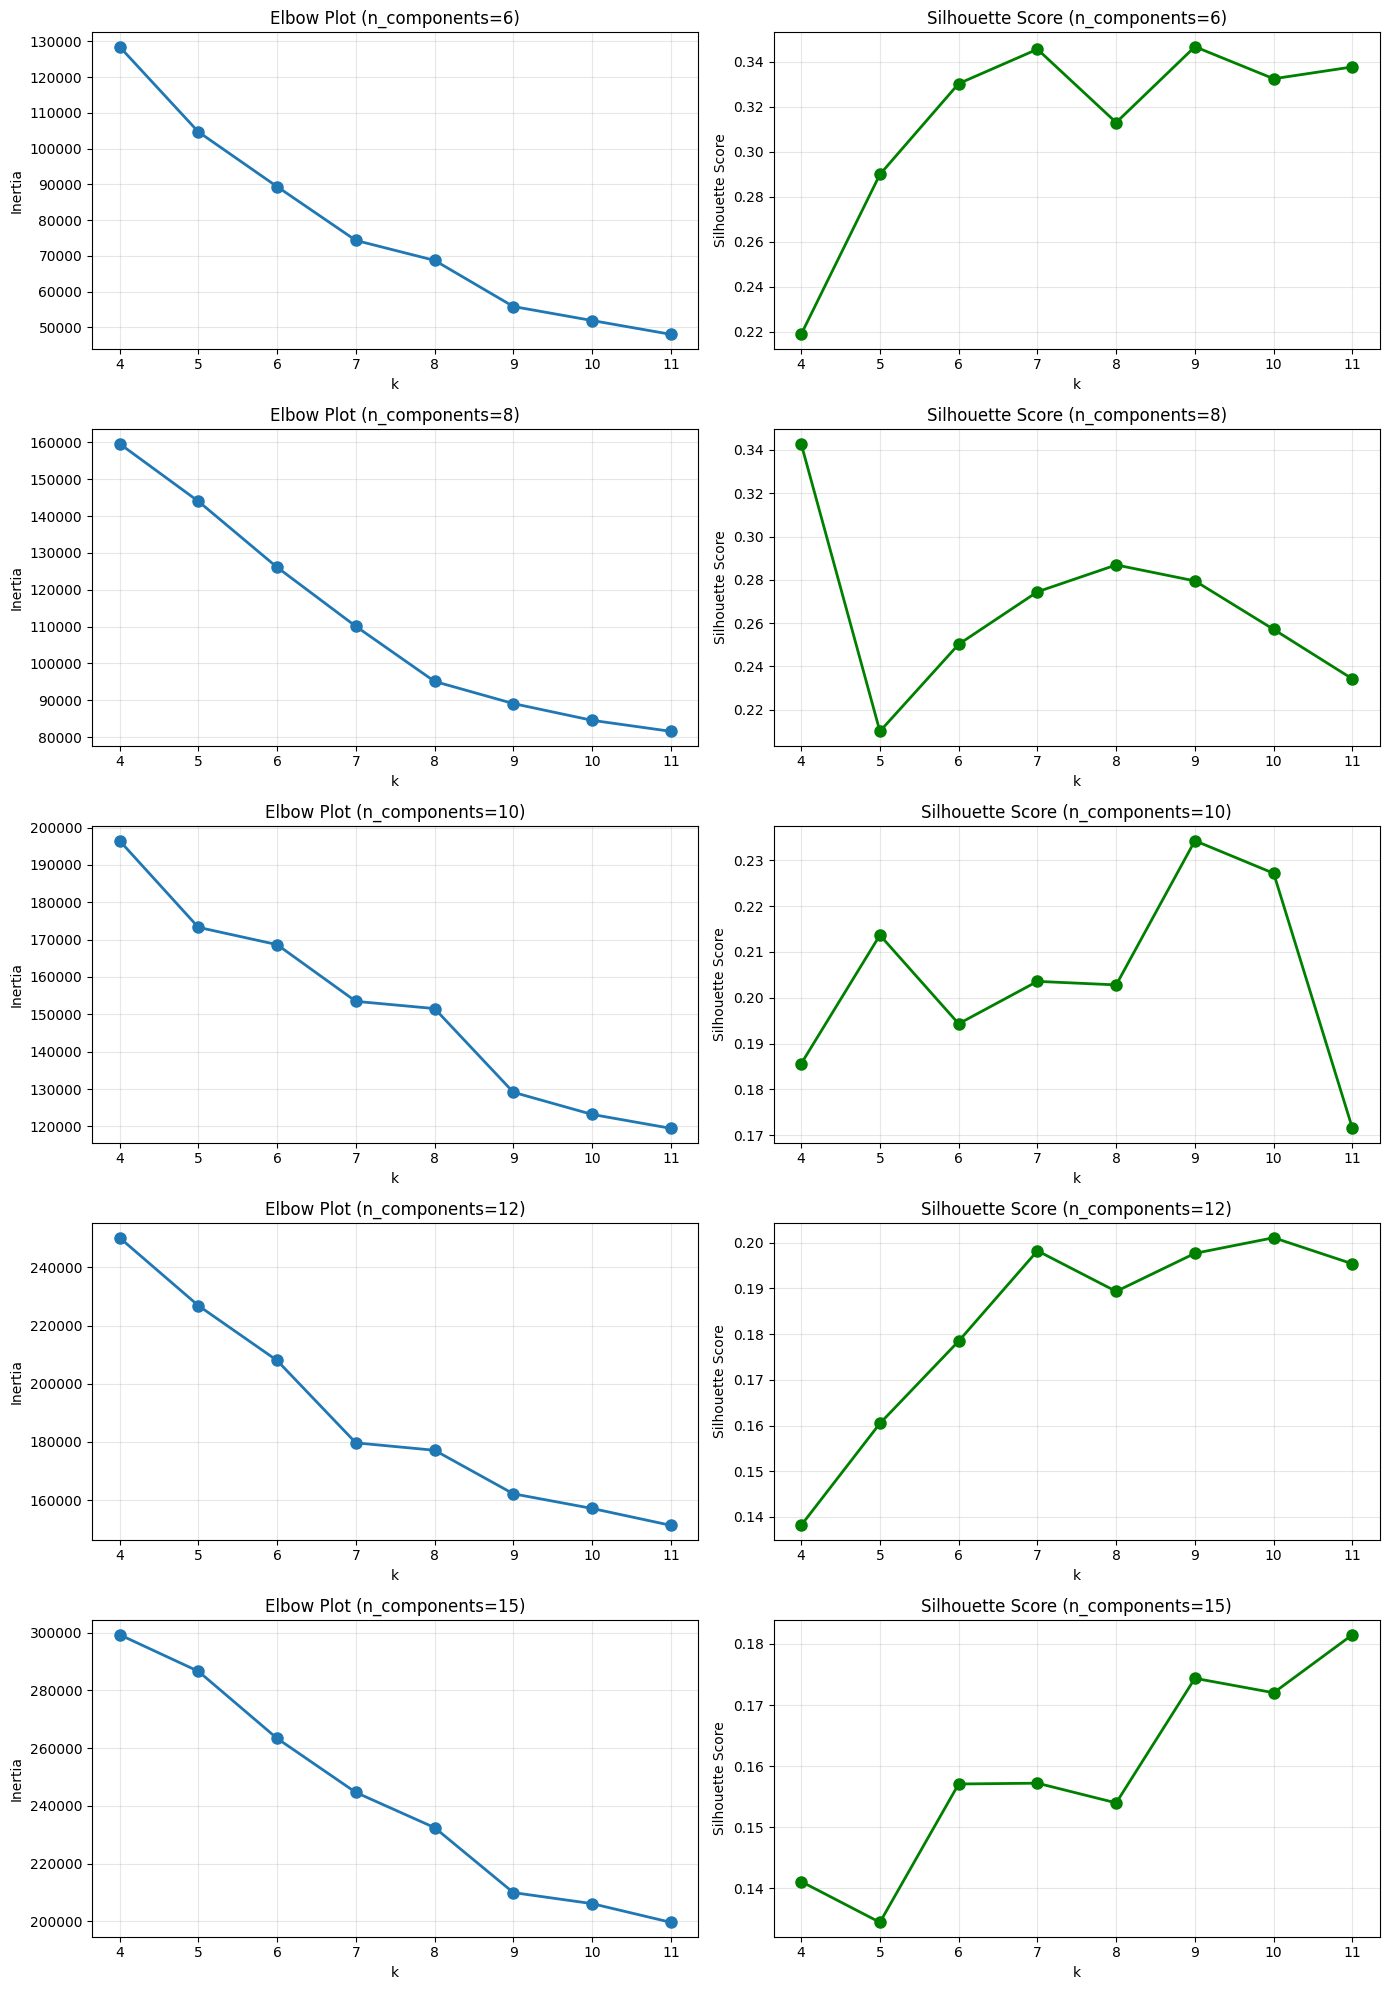


Summary of best results for each n_components:


,n_components,best_k (silhouette),best_silhouette,silhouette_range
0,6,9,0.3468,0.2189 - 0.3468
1,8,4,0.3428,0.2101 - 0.3428
2,10,9,0.2343,0.1715 - 0.2343
3,12,10,0.2011,0.1382 - 0.2011
4,15,11,0.1815,0.1344 - 0.1815


In [43]:
# Create comparison plots for all n_components
fig, axes = plt.subplots(len(n_components_list), 2, figsize=(14, 4*len(n_components_list)))

for idx, n_comp in enumerate(n_components_list):
    results = all_results[n_comp]
    ks = results['k_list']
    sil = results['silhouette']
    inertia = results['inertia']
    
    # Elbow plot
    axes[idx, 0].plot(ks, inertia, marker='o', linewidth=2, markersize=8)
    axes[idx, 0].set_title(f'Elbow Plot (n_components={n_comp})')
    axes[idx, 0].set_xlabel('k')
    axes[idx, 0].set_ylabel('Inertia')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Silhouette plot
    axes[idx, 1].plot(ks, sil, marker='o', linewidth=2, markersize=8, color='green')
    axes[idx, 1].set_title(f'Silhouette Score (n_components={n_comp})')
    axes[idx, 1].set_xlabel('k')
    axes[idx, 1].set_ylabel('Silhouette Score')
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create summary table
summary_data = []
for n_comp in n_components_list:
    results = all_results[n_comp]
    best_k_sil = results['k_list'][np.argmax(results['silhouette'])]
    best_sil = max(results['silhouette'])
    summary_data.append({
        'n_components': n_comp,
        'best_k (silhouette)': best_k_sil,
        'best_silhouette': f'{best_sil:.4f}',
        'silhouette_range': f'{min(results["silhouette"]):.4f} - {max(results["silhouette"]):.4f}'
    })

summary_df = pd.DataFrame(summary_data)
print("\nSummary of best results for each n_components:")
print("=" * 80)
display(summary_df)
print("=" * 80)

In [44]:
# Detailed results table for each n_components
print("\n" + "=" * 80)
print("DETAILED RESULTS FOR EACH n_components")
print("=" * 80)

for n_comp in n_components_list:
    results = all_results[n_comp]
    eval_df = pd.DataFrame({
        'k': results['k_list'],
        'inertia': results['inertia'],
        'silhouette': results['silhouette']
    })
    print(f"\nn_components = {n_comp}:")
    print("-" * 60)
    display(eval_df)


DETAILED RESULTS FOR EACH n_components

n_components = 6:
------------------------------------------------------------


,k,inertia,silhouette
0,4,128474.687500,0.218931
1,5,104680.281250,0.289998
2,6,89372.328125,0.330361
3,7,74339.164062,0.345636
4,8,68758.507812,0.313066
5,9,55863.250000,0.346754
6,10,51949.156250,0.332520
7,11,48087.937500,0.337773



n_components = 8:
------------------------------------------------------------


,k,inertia,silhouette
0,4,159658.140625,0.342833
1,5,144024.468750,0.210065
2,6,126101.804688,0.250252
3,7,110070.820312,0.274476
4,8,95109.210938,0.286881
5,9,89094.765625,0.279505
6,10,84549.671875,0.257115
7,11,81556.609375,0.234264



n_components = 10:
------------------------------------------------------------


,k,inertia,silhouette
0,4,196480.984375,0.185590
1,5,173289.609375,0.213657
2,6,168659.015625,0.194321
3,7,153469.515625,0.203570
4,8,151536.312500,0.202800
5,9,129126.039062,0.234260
6,10,123195.000000,0.227150
7,11,119468.359375,0.171501



n_components = 12:
------------------------------------------------------------


,k,inertia,silhouette
0,4,250159.468750,0.138165
1,5,226841.921875,0.160470
2,6,207986.312500,0.178473
3,7,179699.375000,0.198238
4,8,177148.843750,0.189354
5,9,162197.546875,0.197685
6,10,157164.140625,0.201100
7,11,151363.937500,0.195388



n_components = 15:
------------------------------------------------------------


,k,inertia,silhouette
0,4,299341.937500,0.141125
1,5,286660.687500,0.134450
2,6,263384.000000,0.157088
3,7,244643.000000,0.157220
4,8,232438.328125,0.153995
5,9,209910.890625,0.174383
6,10,206083.546875,0.172020
7,11,199596.390625,0.181515


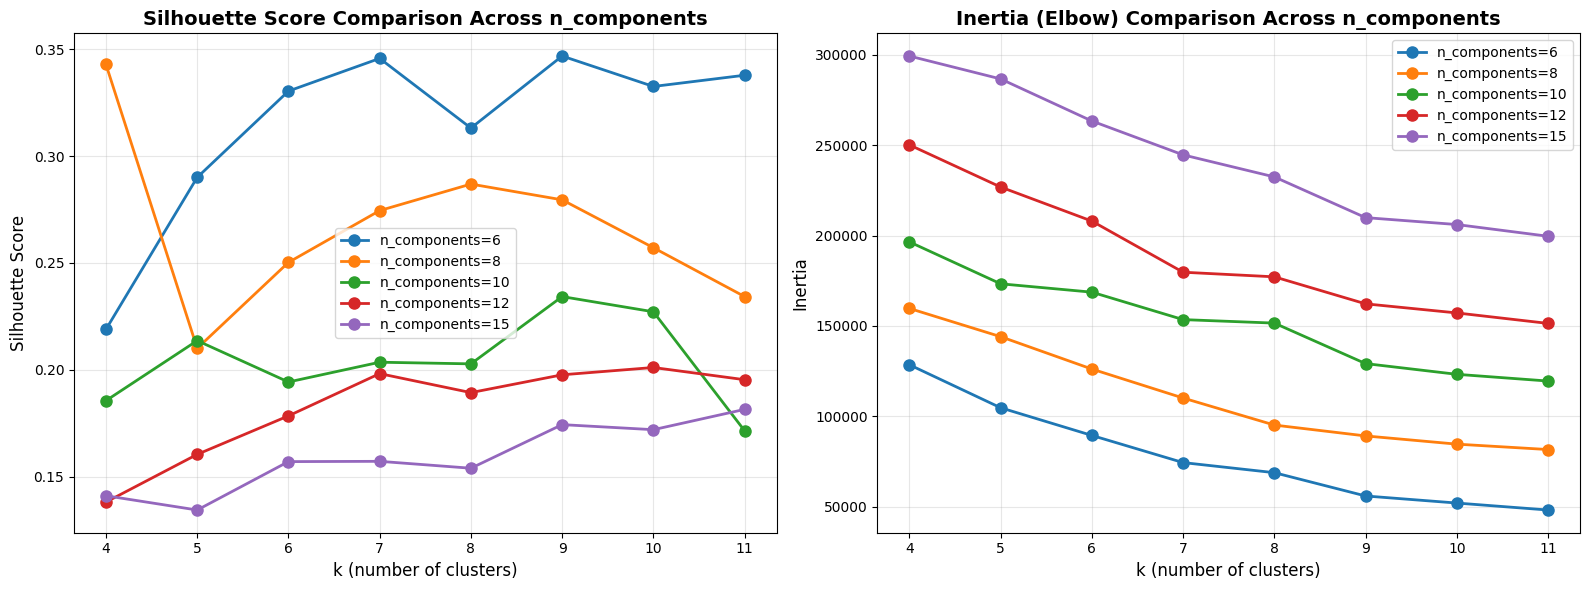

In [45]:
# Overlay comparison plot: Silhouette scores across all n_components
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Silhouette scores comparison
for n_comp in n_components_list:
    results = all_results[n_comp]
    ax1.plot(results['k_list'], results['silhouette'], 
              marker='o', linewidth=2, markersize=8, 
              label=f'n_components={n_comp}')

ax1.set_title('Silhouette Score Comparison Across n_components', fontsize=14, fontweight='bold')
ax1.set_xlabel('k (number of clusters)', fontsize=12)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Inertia comparison
for n_comp in n_components_list:
    results = all_results[n_comp]
    ax2.plot(results['k_list'], results['inertia'], 
             marker='o', linewidth=2, markersize=8, 
             label=f'n_components={n_comp}')

ax2.set_title('Inertia (Elbow) Comparison Across n_components', fontsize=14, fontweight='bold')
ax2.set_xlabel('k (number of clusters)', fontsize=12)
ax2.set_ylabel('Inertia', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
from sklearn.cluster import KMeans

# Use n_components=10 for final clustering
n_components_final = 6
k_final = 7

# Get the FAMD transformed data for n_components=10
X_final = all_results[n_components_final]['X']

print(f"Using n_components={n_components_final} with k={k_final} for final clustering")
print(f"Data shape: {X_final.shape}")

# Fit final KMeans
km_final = KMeans(
    n_clusters=k_final,
    n_init="auto",
    random_state=42
)

df["cluster"] = km_final.fit_predict(X_final)

# Add prefix to cluster labels
df["cluster"] = "business_" + df["cluster"].astype(str)

print("\nCluster sizes:")
print(df["cluster"].value_counts().sort_index())

Using n_components=6 with k=7 for final clustering
Data shape: (8311, 6)

Cluster sizes:
cluster
business_0    4317
business_1    1194
business_2     108
business_3    1616
business_4     652
business_5     246
business_6     178
Name: count, dtype: int64


In [47]:
# Restore customer_id from df_full for merging
# Match business customers from df_full using the filtered indices
business_mask = df_full['kyc_type'].str.lower() == 'business'
df_full_business = df_full[business_mask].copy().reset_index(drop=True)
df_with_id = df.reset_index(drop=True).copy()
df_with_id['customer_id'] = df_full_business['customer_id'].values

# Save cluster results to separate business CSV (for reference)
output_path_business = "../Clustering/Kmeans_Business.csv"
df_with_id.to_csv(output_path_business, index=False)
print(f"Business cluster results saved to {output_path_business}")
print(f"Total rows saved: {len(df_with_id)}")
print(f"Columns saved: {len(df_with_id.columns)}")

# Save to combined Kmeans_Seperate.csv
output_path_separate = "../Clustering/Kmeans_Seperate.csv"

# Create dataframe with customer_id and cluster label
business_clusters = df_with_id[['customer_id', 'cluster']].copy()

# Check if Kmeans_Seperate.csv exists
if Path(output_path_separate).exists():
    # Read existing file and merge business cluster labels
    df_separate = pd.read_csv(output_path_separate)
    print(f"\nFound existing {output_path_separate} with {len(df_separate)} rows")
    
    # Merge business cluster labels
    if 'cluster' in df_separate.columns:
        # Update existing cluster column for business customers
        df_separate = df_separate.merge(business_clusters, on='customer_id', how='left', suffixes=('', '_new'))
        df_separate['cluster'] = df_separate['cluster_new'].fillna(df_separate['cluster'])
        df_separate = df_separate.drop(columns=['cluster_new'])
    else:
        # Add cluster column
        df_separate = df_separate.merge(business_clusters, on='customer_id', how='left')
else:
    # Create new file from full dataframe with business cluster labels
    df_separate = df_full[['customer_id']].copy()
    df_separate = df_separate.merge(business_clusters, on='customer_id', how='left')
    print(f"\nCreating new {output_path_separate}")

# Save to Kmeans_Seperate.csv
df_separate.to_csv(output_path_separate, index=False)
print(f"\n✓ Saved to {output_path_separate}")
print(f"  Total rows: {len(df_separate)}")
print(f"  Business customers with cluster labels: {df_separate['cluster'].str.startswith('business_', na=False).sum()}")
print(f"  Individual customers with cluster labels: {df_separate['cluster'].str.startswith('individual_', na=False).sum()}")
print(f"  Customers without cluster labels: {df_separate['cluster'].isna().sum()}")

Business cluster results saved to ../Clustering/Kmeans_Business.csv
Total rows saved: 8311
Columns saved: 32

Found existing ../Clustering/Kmeans_Seperate.csv with 61410 rows

✓ Saved to ../Clustering/Kmeans_Seperate.csv
  Total rows: 61410
  Business customers with cluster labels: 8311
  Individual customers with cluster labels: 53099
  Customers without cluster labels: 0


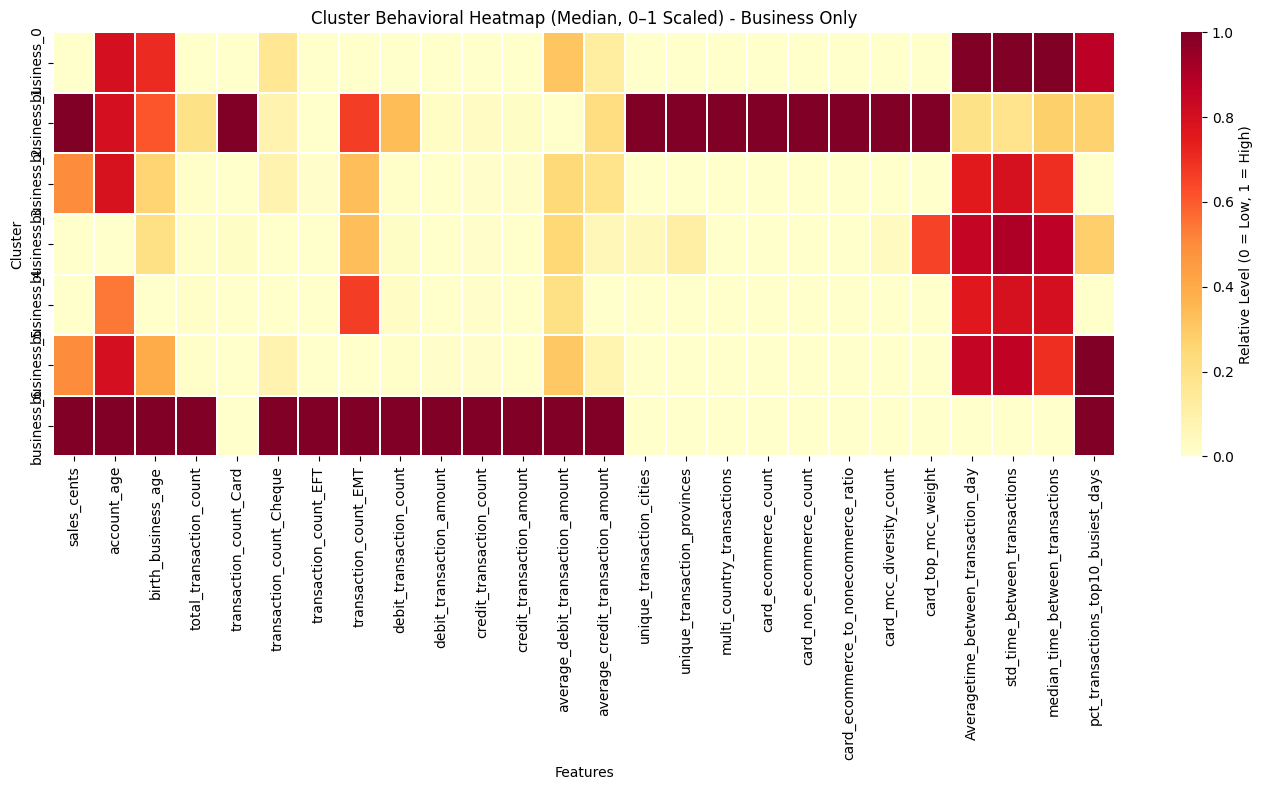

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include="number").columns.drop("cluster", errors="ignore")

# Cluster medians
cluster_medians = df.groupby("cluster")[num_cols].median()

# Min–max scale per feature (column-wise)
cluster_medians_01 = (
    cluster_medians - cluster_medians.min()
) / (cluster_medians.max() - cluster_medians.min())

plt.figure(figsize=(14, 8))
sns.heatmap(
    cluster_medians_01,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Relative Level (0 = Low, 1 = High)"}
)

plt.title("Cluster Behavioral Heatmap (Median, 0–1 Scaled) - Business Only")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

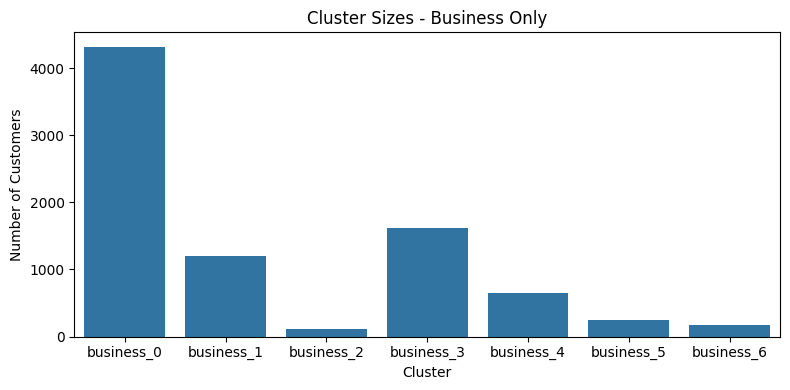

In [49]:
cluster_sizes = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values)
plt.title("Cluster Sizes - Business Only")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

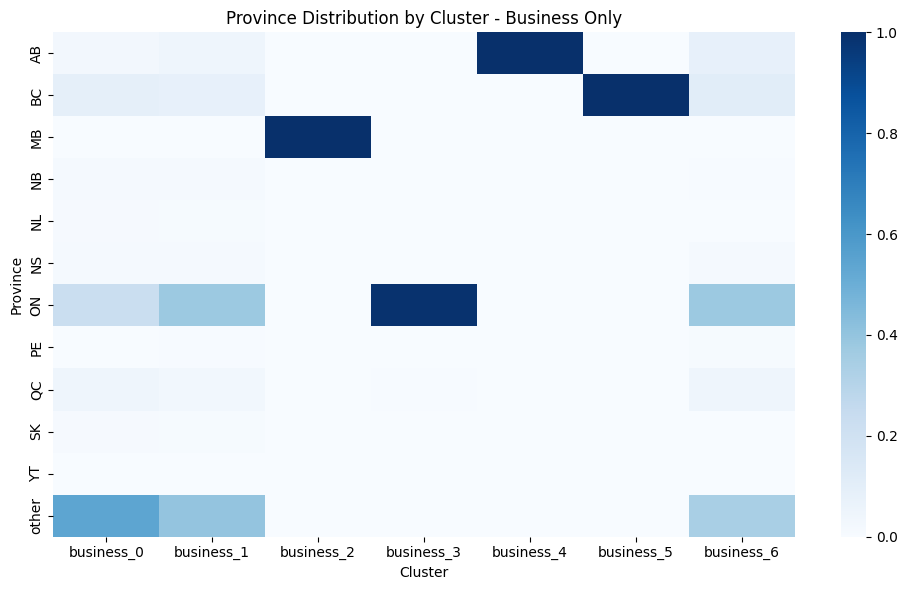

In [50]:
province_dist = pd.crosstab(
    df["province"],
    df["cluster"],
    normalize="columns"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    province_dist,
    cmap="Blues"
)
plt.title("Province Distribution by Cluster - Business Only")
plt.xlabel("Cluster")
plt.ylabel("Province")
plt.tight_layout()
plt.show()

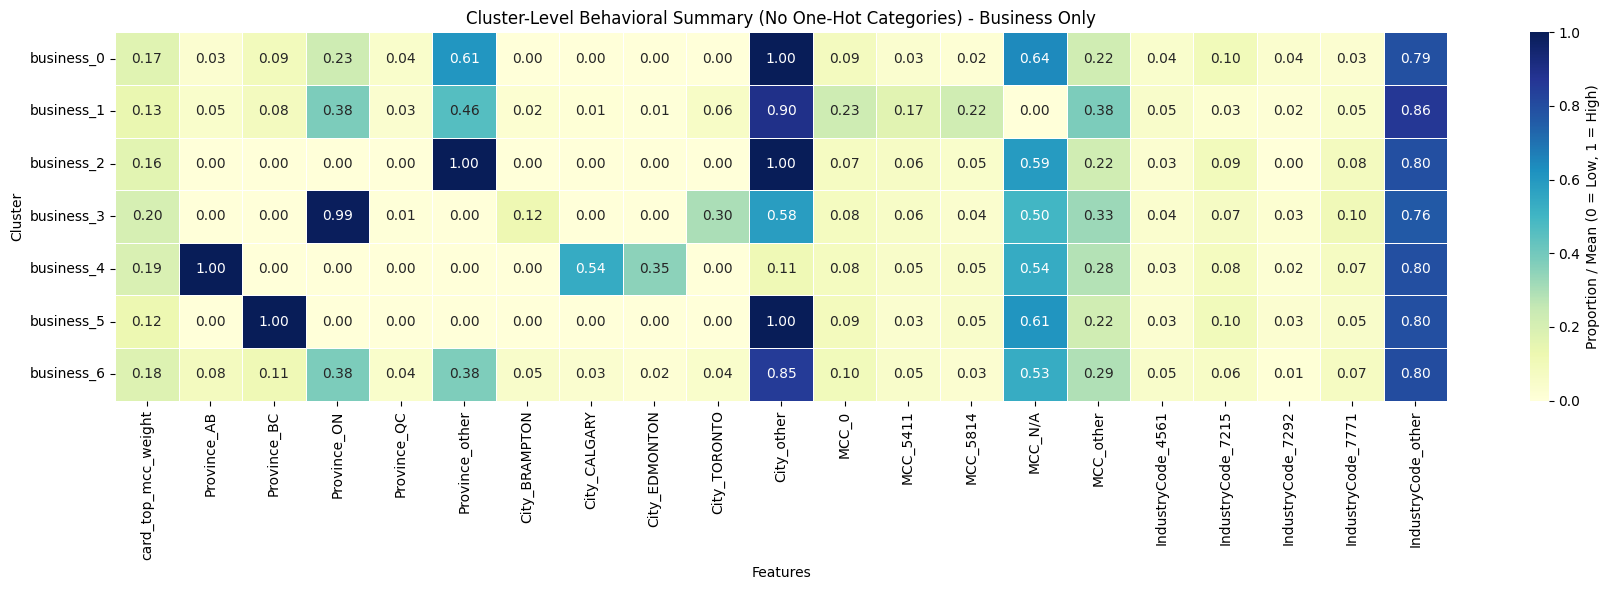

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# Helper: categorical proportions
# ===============================
def categorical_cluster_proportions(df, cluster_col, cat_col, top_n=5):
    """
    Rows = clusters
    Columns = top-N categories (+ other)
    Values = proportion within cluster
    """
    # Convert to string if categorical to avoid type errors
    col_series = df[cat_col].astype(str) if df[cat_col].dtype.name == 'category' else df[cat_col]
    
    top_vals = col_series.value_counts().head(top_n).index
    collapsed = col_series.where(col_series.isin(top_vals), "other")

    return pd.crosstab(
        df[cluster_col],
        collapsed,
        normalize="index"
    )


# ===============================
# Build heatmap dataframe
# ===============================
heatmap_df = pd.DataFrame(
    index=sorted(df["cluster"].unique())
)

# ---- Numeric dominance / indicator-style features ----
heatmap_df["card_top_mcc_weight"] = (
    df.groupby("cluster")["card_top_mcc_weight"].mean()
)


# ---- Categorical summaries (NO one-hot) ----

# Province (top 5)
prov_prop = categorical_cluster_proportions(df, "cluster", "province", top_n=5)
prov_prop.columns = [f"Province_{c}" for c in prov_prop.columns]
heatmap_df = heatmap_df.join(prov_prop)

# City (top 5)
city_prop = categorical_cluster_proportions(df, "cluster", "city", top_n=5)
city_prop.columns = [f"City_{c}" for c in city_prop.columns]
heatmap_df = heatmap_df.join(city_prop)

# Top MCC (top 5)
mcc_prop = categorical_cluster_proportions(df, "cluster", "card_top_mcc", top_n=5)
mcc_prop.columns = [f"MCC_{c}" for c in mcc_prop.columns]
heatmap_df = heatmap_df.join(mcc_prop)

# Industry code (top 5)
industry_code_prop = categorical_cluster_proportions(df, "cluster", "industry_code", top_n=5)
industry_code_prop.columns = [f"IndustryCode_{c}" for c in industry_code_prop.columns]
heatmap_df = heatmap_df.join(industry_code_prop)


# ===============================
# Plot heatmap (same style as example)
# ===============================
plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Proportion / Mean (0 = Low, 1 = High)"}
)

plt.title("Cluster-Level Behavioral Summary (No One-Hot Categories) - Business Only")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [52]:
# Create a transposed DataFrame
transposed_df = df.transpose()

# Get a boolean mask for duplicate columns (as rows in the transposed df)
# keep='first' marks the first occurrence as False and all others as True
duplicate_columns_mask = transposed_df.duplicated(keep='first')

# Get the names of the columns that are duplicates
duplicate_column_names_by_value = df.columns[duplicate_columns_mask]

duplicate_column_names_by_value

Index([], dtype='object')